Probability distribution of the proton latent vectors to then find the deuterons. 

In [69]:
import numpy as np
import umap
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [88]:
latent_p = np.load('latent_p.npy'); print(latent_p.shape)
latent_d = np.load('latent_d.npy'); print(latent_d.shape)

latent_all = np.concatenate([latent_p, latent_d])
labels = np.concatenate([
    np.zeros(len(latent_p)),          # 0 = protons
    np.ones(len(latent_d))         # 1 = deuterons
])

(6291, 16)
(5115, 16)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_76306/170009718.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')


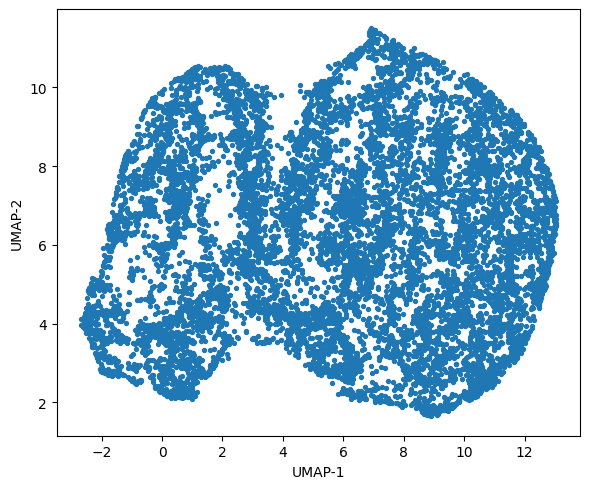

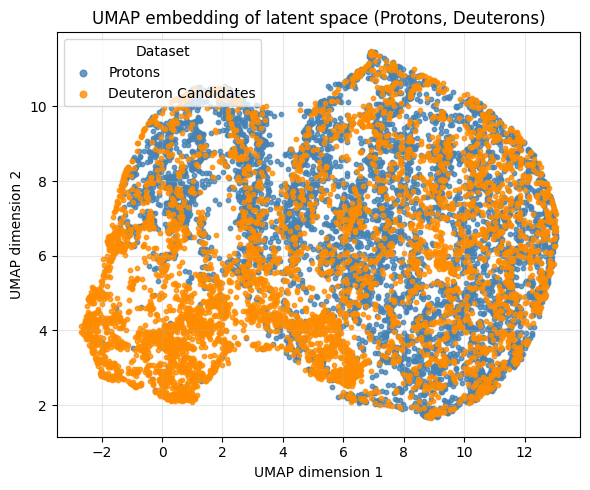

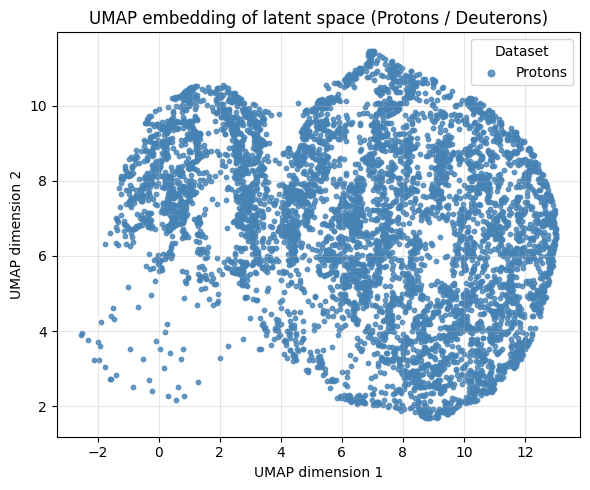

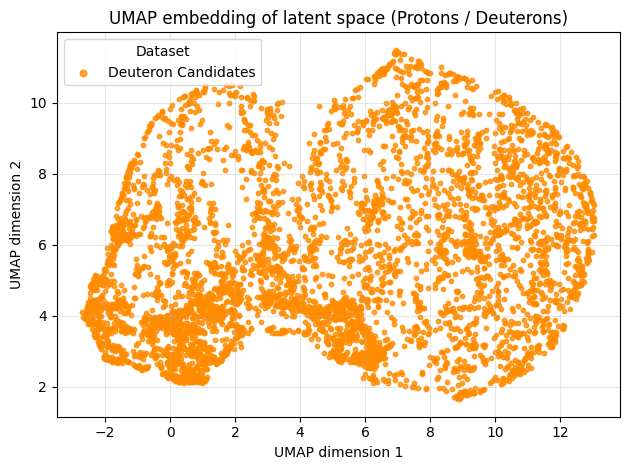

In [89]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)

latent_umap = reducer.fit_transform(latent_all)

plt.figure(figsize=(6,5))
plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

palette = ['steelblue', 'darkorange'] 

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
    plt.title("UMAP embedding of latent space (Protons / Deuterons)")
    plt.legend(title="Dataset", markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [90]:
print("Has NaN:", np.isnan(latent_p).any())
print("Has Inf:", np.isinf(latent_p).any())
print("Min, Max:", np.min(latent_p), np.max(latent_p))
print("Mean std per dimension:", np.std(latent_p, axis=0))

Has NaN: False
Has Inf: False
Min, Max: -126.46029 122.26913
Mean std per dimension: [19.79551  19.231127 21.377674 25.032299 21.900362 20.477596 21.806711
 22.021332 18.369852 22.669516 20.048628 22.112131 17.872648 25.029387
 19.27069  19.744745]


In [91]:
p = StandardScaler().fit_transform(latent_p).astype(np.float64)
d = StandardScaler().fit_transform(latent_d).astype(np.float64)

all = np.concatenate([p, d])
labels = np.concatenate([
    np.zeros(len(p)),          # 0 = protons
    np.ones(len(d))         # 1 = deuterons
])

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/cm/m55y72dj6cd5lkwrfdb2bpnr0000gp/T/ipykernel_76306/1725321528.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')


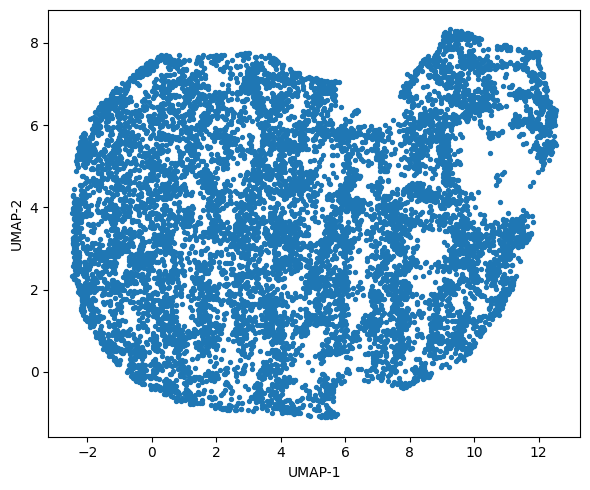

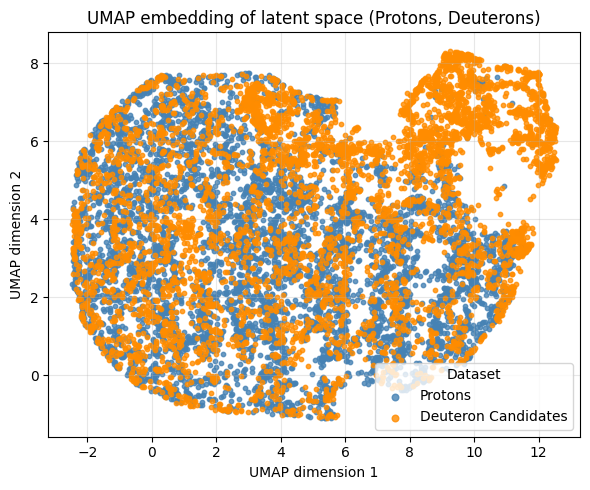

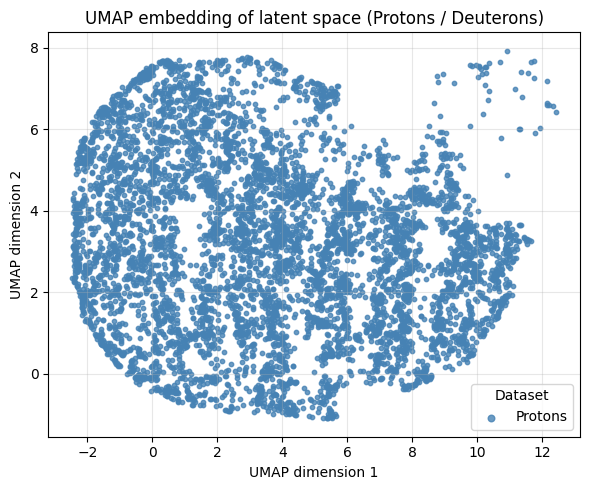

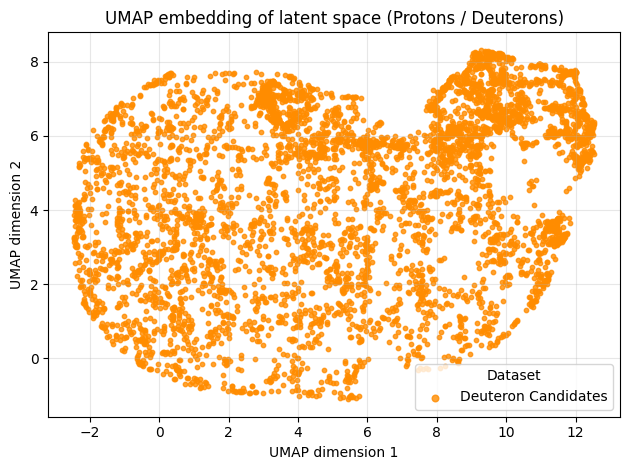

In [92]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)

latent_umap = reducer.fit_transform(all)

plt.figure(figsize=(6,5))
plt.scatter(latent_umap[:, 0], latent_umap[:, 1], s=8, cmap='tab20')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

palette = ['steelblue', 'darkorange'] 

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
for i, name in enumerate(['Protons', 'Deuteron Candidates']):
    m = (labels == i)
    plt.scatter(latent_umap[m, 0], latent_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.xlabel("UMAP dimension 1")
    plt.ylabel("UMAP dimension 2")
    plt.title("UMAP embedding of latent space (Protons / Deuterons)")
    plt.legend(title="Dataset", markerscale=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [93]:
print("Has NaN:", np.isnan(p).any())
print("Has Inf:", np.isinf(p).any())
print("Min, Max:", np.min(p), np.max(p))
print("Mean std per dimension:", np.std(p, axis=0))

Has NaN: False
Has Inf: False
Min, Max: -6.387491703033447 5.32012414932251
Mean std per dimension: [1.         1.         1.         0.99999999 1.         1.
 1.         1.         1.         1.00000001 0.99999999 1.
 1.         1.         1.         1.        ]


In [60]:
from sklearn.mixture import GaussianMixture

def fit_gmm_stable(X, k):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',   # avoids ill-conditioned inversions
        init_params='random',     # avoid KMeans initialisation
        reg_covar=1e-3,           # strong stabiliser; can later reduce
        n_init=5,
        max_iter=500,
        random_state=42
    )
    gmm.fit(X)
    return gmm

for k in range(1, 50):
    g = fit_gmm_stable(p, k)
    print(f"k={k}, logL={g.score(p):.2f}, AIC={g.aic(p):.0f}, BIC={g.bic(p):.0f}")


k=1, logL=-20.44, AIC=257432, BIC=258457
k=2, logL=-14.00, AIC=176709, BIC=178767
k=3, logL=-12.06, AIC=152670, BIC=155760
k=4, logL=-10.87, AIC=137929, BIC=142052
k=5, logL=-10.00, AIC=127300, BIC=132455
k=6, logL=-8.84, AIC=113120, BIC=119307
k=7, logL=-8.25, AIC=105933, BIC=113152
k=8, logL=-7.58, AIC=97878, BIC=106129
k=9, logL=-7.10, AIC=92137, BIC=101421
k=10, logL=-6.90, AIC=89873, BIC=100189
k=11, logL=-6.37, AIC=83495, BIC=94843
k=12, logL=-6.09, AIC=80248, BIC=92629
k=13, logL=-5.88, AIC=77985, BIC=91398
k=14, logL=-5.64, AIC=75215, BIC=89660
k=15, logL=-5.45, AIC=73182, BIC=88659
k=16, logL=-5.07, AIC=68682, BIC=85191
k=17, logL=-5.25, AIC=71277, BIC=88819
k=18, logL=-4.70, AIC=64688, BIC=83262
k=19, logL=-4.72, AIC=65171, BIC=84777
k=20, logL=-4.70, AIC=65240, BIC=85878
k=21, logL=-4.60, AIC=64347, BIC=86018
k=22, logL=-4.49, AIC=63252, BIC=85955
k=23, logL=-4.40, AIC=62457, BIC=86193
k=24, logL=-4.04, AIC=58192, BIC=82959
k=25, logL=-4.19, AIC=60404, BIC=86204
k=26, logL=-

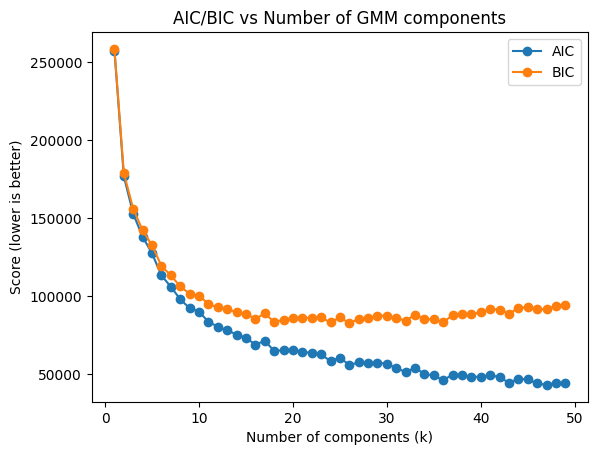

In [ ]:
K = list(range(1, 50))
AIC = [257432,176709,152670,137929,127300,113120,105933,97878,92137,89873,
       83495,80248,77985,75215,73182,68682,71277,64688,65171,65240,
       64347,63252,62457,58192,60404,55696,57323,56907,57261,56481,
       53661,51205,53927,49950,48989,45899,49597,49156,47961,48240,
       49150,47932,44226,46892,46405,43921,42913,44239,43908]
BIC = [258457,178767,155760,142052,132455,119307,113152,106129,101421,100189,
       94843,92629,91398,89660,88659,85191,88819,83262,84777,85878,
       86018,85955,86193,82959,86204,82528,85187,85804,87191,87442,
       85655,84231,87985,85040,85112,83054,87784,88375,88213,89524,
       91466,91281,88607,92305,92851,91399,91423,93781,94482]

plt.plot(K, AIC, label='AIC', marker='o')
plt.plot(K, BIC, label='BIC', marker='o')
plt.xlabel('Number of components (k)')
plt.ylabel('Score (lower is better)')
plt.legend()
plt.title('AIC/BIC vs Number of GMM components')
plt.show()


In [62]:
best_k = 20
best_gmm = fit_gmm_stable(p, best_k)

In [63]:
print("Weights:", best_gmm.weights_)
print("Means shape:", best_gmm.means_.shape)
print("Covariances shape:", best_gmm.covariances_.shape)

Weights: [0.03701433 0.0945714  0.02882258 0.07298548 0.08157408 0.02960298
 0.03913074 0.15274579 0.04750884 0.03095391 0.03780619 0.0135919
 0.02538465 0.05524764 0.03835318 0.03707036 0.051108   0.04665858
 0.02037493 0.05949445]
Means shape: (20, 16)
Covariances shape: (20, 16, 16)


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


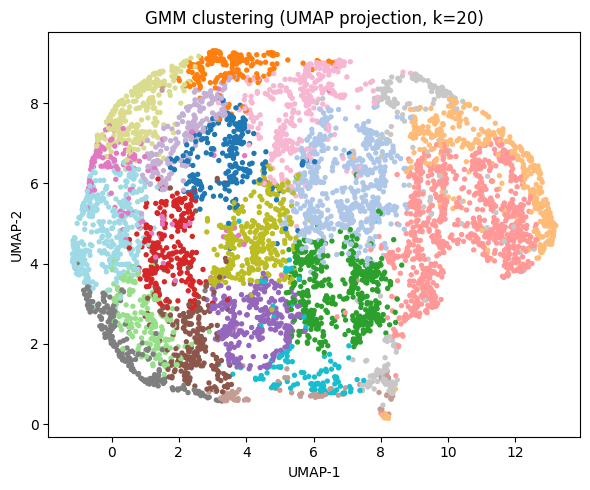

In [66]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(p)

labels = best_gmm.predict(p)

plt.figure(figsize=(6,5))
plt.scatter(Z_umap[:, 0], Z_umap[:, 1], c=labels, s=8, cmap='tab20')
plt.title(f"GMM clustering (UMAP projection, k={best_k})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

In [68]:
logL_d = best_gmm.score_samples(d)
logL_p = best_gmm.score_samples(p)

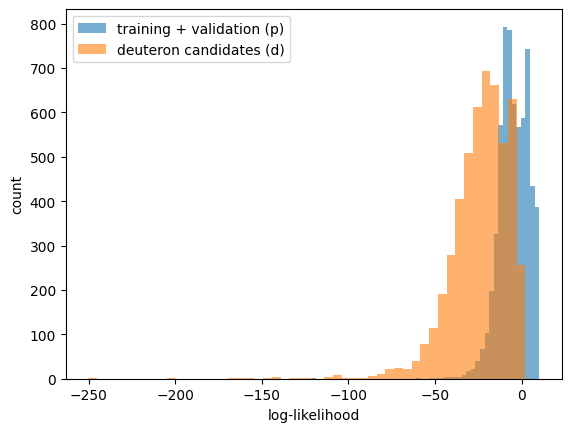

In [73]:
plt.hist(logL_p, bins=50, alpha=0.6, label='training + validation (p)')
plt.hist(logL_d, bins=50, alpha=0.6, label='deuteron candidates (d)')
plt.xlabel('log-likelihood')
plt.ylabel('count')
plt.legend()
plt.show()